In [2]:
from rdkit import Chem
from rdkit.Chem import Recap, BRICS
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import rdScaffoldNetwork
from rdkit.Chem import AllChem

from rdkit.Chem import rdmolops
import scaffoldgraph as sg


/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#  4,C=c1cc2c(=Cc3ccc(C)s3)oc(O)c2c(=S)[nH]1,[1*]c1ccc(C=c2oc([2*])c3c(=S)[nH]c(=C)cc23)s1,[1*]C.[2*]O,CHEMBL1000314,B,1

mols = list(map(lambda s:Chem.MolFromSmiles(s), 
    '''CCc1c(Oc2cc(C)cc(C)c2)n(CCC2CCCC2)c(=O)[nH]c1=O
    Nc1ccc(-c2ccc(OCc3nnc(SC4CCCC4)n3-c3cccnc3)cc2)cc1
    CCCCNC(=O)c1cnn2c(C)c(Cc3c(C)cc(C)cc3C)c(C)nc12
    O=C(NCc1ccco1)C1CCN(S(=O)(=O)c2ccc(Cl)cc2)CC1'''.split()
))

In [4]:

def tree_frags_from_mol(mol, weight_ratio=0.5):
    scaffold = sg.core.Scaffold(sg.core.fragment.get_murcko_scaffold(mol))
    rdmolops.RemoveStereochemistry(scaffold.mol)
    parents = [scaffold]
    # fragmenter = sg.core.MurckoRingFragmenter(use_scheme_4=True)
    fragmenter = sg.core.MurckoRingSystemFragmenter()
    minimal_core_weight = AllChem.CalcExactMolWt(mol) * weight_ratio 
    rules = sg.prioritization.original_ruleset

    def _next_scaffold(child):
        next_parents = [p for p in fragmenter.fragment(child) if (p and AllChem.CalcExactMolWt(p.mol)> minimal_core_weight)]
        if not next_parents:
            return
        next_parent = rules(child, next_parents)
        parents.append(next_parent)
        if next_parent.rings.count > 1:
            _next_scaffold(next_parent)

    _next_scaffold(scaffold)

    return [p.mol for p in parents]

In [5]:
from itertools import zip_longest

def show_tree(mols,w):
    frags = {}
    for i, mol in enumerate(mols):
        frags[i] = tree_frags_from_mol(mol,w)
    frags_list = sum(map(list,zip_longest(*frags.values())), [])
        
    return Draw.MolsToGridImage(frags_list,
                        molsPerRow=4, subImgSize=(200,200))

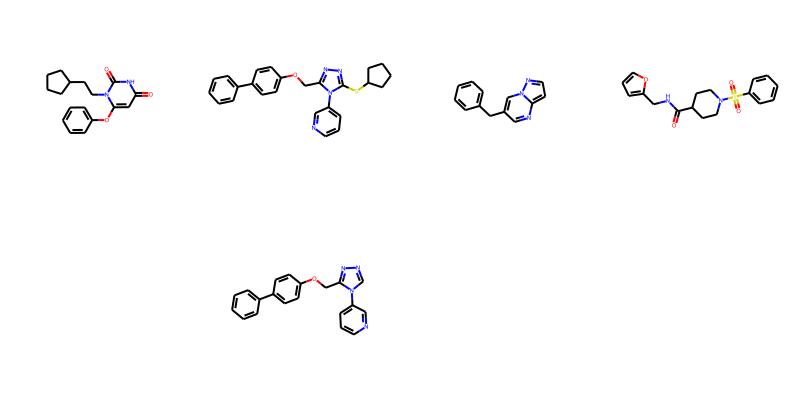

In [6]:
show_tree(mols,0.7)


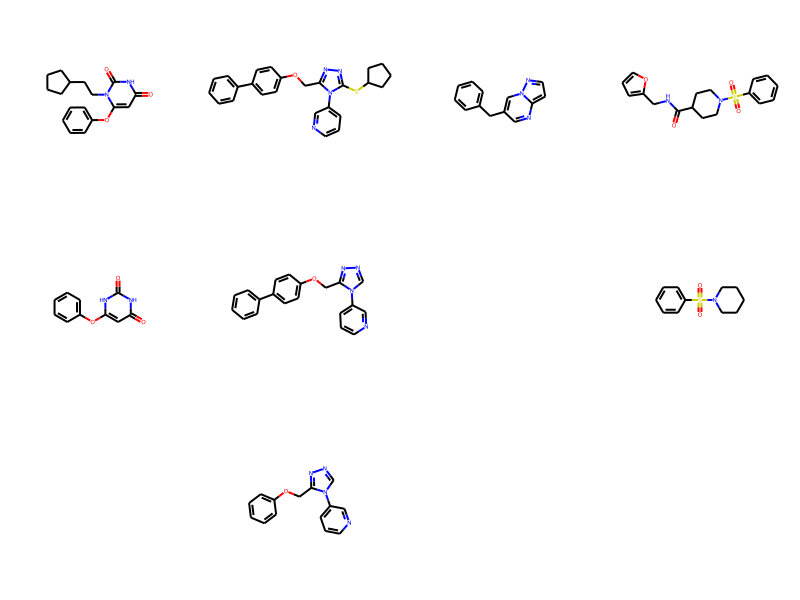

In [7]:
show_tree(mols,0.5)


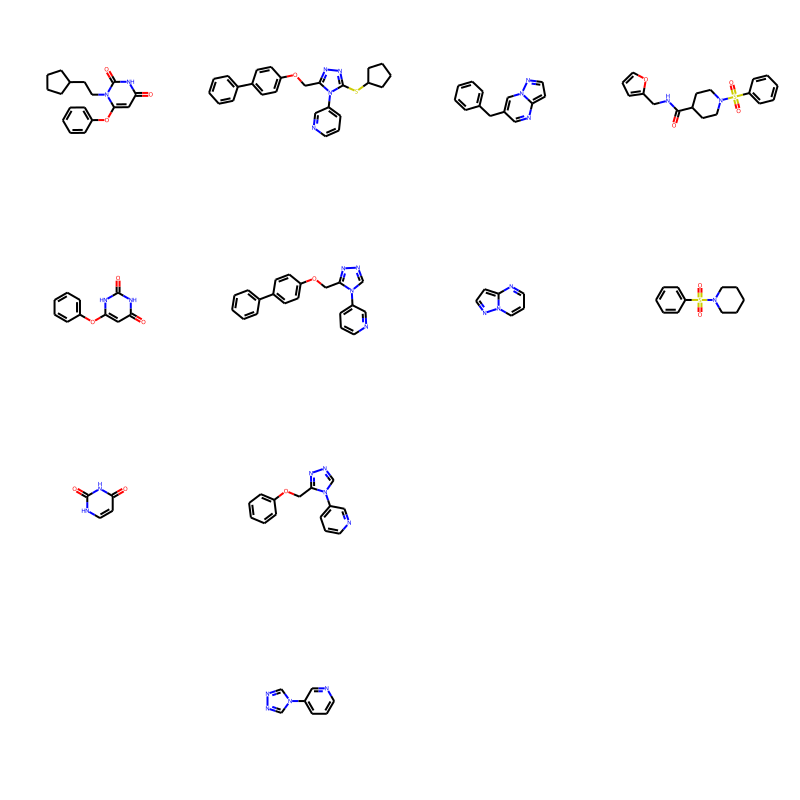

In [8]:
show_tree(mols,0.3)


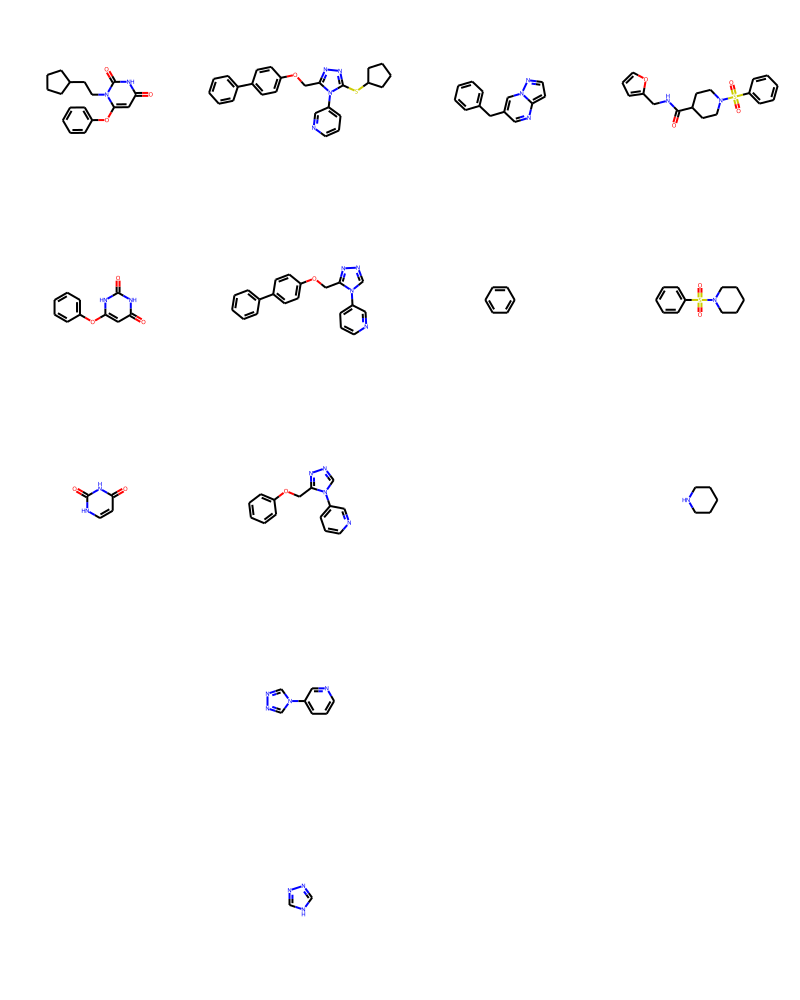

In [9]:
show_tree(mols,0)


In [24]:
import pandas as pd
from rdkit import Chem
fails = []
res = []
i=0
def flip(sdf_file):
    
    mol = Chem.SDMolSupplier(sdf_file)[0]
    if mol is None:
        return 1
    sml = Chem.MolToSmiles(mol)
    try:
        tree_frags_from_mol(mol,0)
    except Exception as e:
        print(e)
        fails.append((sml, str(e)))
        return 2
    return sml


df = pd.read_csv('data/fsdock/valid_tasks.csv')
for p in df['ligand_path'].values:
    res.append(flip(p))

[20:01:27] non-ring atom 9 marked aromatic
[20:01:27] non-ring atom 9 marked aromatic
[20:01:27] non-ring atom 9 marked aromatic
[20:01:27] non-ring atom 9 marked aromatic
[20:01:27] ERROR: Cannot convert ' O ' to int on line 5
[20:01:27] ERROR: moving to the beginning of the next molecule
[20:01:34] non-ring atom 0 marked aromatic
[20:01:34] non-ring atom 5 marked aromatic
[20:01:34] non-ring atom 0 marked aromatic
[20:01:34] non-ring atom 5 marked aromatic
[20:01:36] non-ring atom 0 marked aromatic
[20:01:36] non-ring atom 5 marked aromatic
[20:01:36] non-ring atom 0 marked aromatic
[20:01:36] non-ring atom 5 marked aromatic
[20:01:41] non-ring atom 0 marked aromatic
[20:01:41] non-ring atom 9 marked aromatic
[20:01:41] non-ring atom 5 marked aromatic
[20:01:49] non-ring atom 0 marked aromatic
[20:01:49] non-ring atom 5 marked aromatic
[20:01:49] non-ring atom 0 marked aromatic
[20:01:49] non-ring atom 5 marked aromatic
[20:01:49] non-ring atom 0 marked aromatic
[20:01:49] non-ring a

In [20]:
fails

[('C[C@@H](CN)n1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21', '1'),
 ('C[C@@H](CN)n1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21', '1'),
 ('Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2C1CCCCCC1', '1'),
 ('Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2CC1CCNCC1', '1'),
 ('Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2Cc1ocnc1-c1ccccc1', '1'),
 ('COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1NC(=O)OC(C)(C)C', '1'),
 ('Nc1ncnc2c1c(-c1ccn3ccnc3c1)nn2C1CCCC1', '1'),
 ('CC(C)n1nc(-c2cccc(O)c2)c2c(N)ncnc21', '1'),
 ('Cn1nc(-c2ccc3ccccc3c2)c2c(N)ncnc21', '1'),
 ('Nc1ncnc2[nH]nc(-c3ccccc3)c12', '1'),
 ('Cc1ccc(-c2[nH]nc3ncnc(N)c23)cc1', '1'),
 ('Cc1cccc(-c2[nH]nc3ncnc(N)c23)c1', '1'),
 ('Cc1ccccc1-c1[nH]nc2ncnc(N)c12', '1'),
 ('Cc1cccc(-c2[nH]nc3ncnc(N)c23)c1C', '1'),
 ('CC(C)(C)c1ccc(-c2[nH]nc3ncnc(N)c23)cc1', '1'),
 ('Nc1ncnc2[nH]nc(-c3cccc(O)c3)c12', '1'),
 ('CC(C)n1cc(-c2cccc(O)c2)c2c(N)ncnc21', '1'),
 ('CNc1ncnc2c1c(-c1cccc(O)c1)nn2C(C)C', '1'),
 ('Cc1cc(O)ccc1-c1nn(C(C)C)c2ncnc(N)c12', '1'),
 ('Cc1ccc(-c2[nH]nc3ncnc(N)c23)cc1OCc1ccccc1', '1'),
 ('Cc1ccc(-c2[nH]nc3n